# Discretizing the Richards Equation with Finite Elements
The goal is to discretize the Richards equation, the continuity equation for soil water in the vadose zone. The Richards equation is given by<br>

$\frac{\partial \theta}{\partial h_c}\frac{\partial h_c}{\partial t} - \nabla \cdot (k_r(h_c)K_s(e_z-\nabla h_c)) = W$ <br>

where $\theta$ is the volumetric water content, $h_c$ the capillary head, $k_r$ the relative permeability, $K_s$ the saturated hydraulic conductivity, $e_z$ the unit vector in $z$ direction and $W$ a source/sink term. The term $-k_r(h_c)K_s(e_z-\nabla h_c)$ is the Darcy velocity (cf Darcy's extended law for the unsaturated zone) and we denote it by $q:= - k_r(h_c)K_s(e_z-\nabla h_c) = -k_r(h_c)K_s\nabla(z-h_c).$ <br>
Here, we use the van Genuchten and Mualem parametrization to get: <br>

$k_r(S) = \sqrt{S} (1-(1-S^\frac{N}{N-1})^\frac{N-1}{N})^2,$ <br>
$S(h_c) = (1+(\alpha h_c)^N)^\frac{1-N}{N}$ and <br>
$S = \frac{\theta-\theta_r}{\theta_s-\theta_r}$ <br>

where $S$ is the saturation and $\alpha, N, \theta_r, \theta_s$ are soil-specific parameters which can be found in literature. <br>

Here, we assume steady-state and no source or sink terms, so the PDE transforms to <br>

$- \nabla \cdot (k_r(h_c)K_s(e_z-\nabla h_c)) = 0 ~\qquad (\nabla \cdot q = 0).$ <br>

We want to model a hillslope, so we are going to take a 2D-domain $\Omega$ in $z$- and $x$-direction and assume the following for boundary conditions on $\partial \Omega = \Gamma_{bed} \dot{\cup} \Gamma_{top} \dot{\cup} \Gamma_{D} \dot{\cup} \Gamma_{no}$: <br>
- the left hand side and the bottom are bounded by bedrock, so $q\cdot n = 0$ on $\Gamma_{bed}$
- the top gets constantly infiltrated (constant recharge), so $-q\cdot n = c_{in}$ on $\Gamma_{top}$
- at the right hand side an aquifer builds up to a certain height, such that $h_c=0$ on $\Gamma_D$ and above the water table water cannot flow out, i.e. $q\cdot n = 0$ on $\Gamma_{no}$. <br>
Here, $n$ denotes the unit vector normal to the boundary pointing outwards. <br>

We can now derrive the variational problem: <br>

$0 = \int_\Omega v \nabla\cdot q \, dx = \int_\Omega \nabla \cdot (vq) \,dx - \int_\Omega q\cdot \nabla v \,dx = -\int_\Omega q\cdot \nabla v \,dx + \int_{\partial\Omega} v q\cdot n \,ds = -\int_\Omega q\cdot \nabla v \,dx - \int_{\Gamma_{top}} v c_{in} \,ds$ <br>

Where we assume the test function $v\in V=\{v\in H^1(\Omega):~ v=0 \text{ on } \Gamma_D\}$. The variational problem then states: Find $u\in V$ such that: <br>

$F(u;v):=\int_\Omega k_r(u)K_s(e_z-\nabla u) \cdot \nabla v \,dx - \int_{\Gamma_{top}} v c_{in} \,ds = 0$ for all $v\in V.$ <br>

This is now a nonlinear problem in $u$. We can try and solve this via Picard iterations, or some sort of Newton scheme. <br>
**Picard iteration**: Find $u^{k+1}$ such that $\tilde{F}(u^{k+1};v)=0$ for all $v\in V$ for $\tilde{F}(u^{k+1};v) = \int_\Omega k_r(u^k)K_s(e_z-\nabla u^{k+1}) \cdot \nabla v \,dx - \int_{\Gamma_{top}} v c_{in} \,ds.$ Now, $\tilde F$ is linear in both $u^{k+1}$ and $v$, so the equivalent formulation would be to find $u^{k+1}$ such that $a(u^{k+1}, v) = L(v)$ for all $v\in V$ for $a(u^{k+1}, v) = \int_\Omega k_r(u^k)K_s(e_z-\nabla u^{k+1}) \cdot \nabla v \,dx - \int_{\Gamma_{top}} v c_{in} \,ds$ and $L(v)=0$. This can be solved by the LinearProblem solver.<br>

**Newton scheme**: Find $u_h = \sum\limits_{j=1}^N U_j\phi_j$ such that $b(U=(U_1,...,U_N))=0$ for $b:\mathbb{R}^N \to \mathbb{R}^N$ with $b_i(U)=F(u_h;\hat\phi_i)$ for $i=1,...,N$. This means to solve $A(u_h^k)\delta U^k = -b(U^k)$ and then get $U^{k+1}=U^k+\delta U^k$. Here $(A(u_h))_{ij} = \frac{\partial b_i(U)}{\partial U_j} = \frac{\partial F(u_h;\hat\phi_i)}{\partial U_j} =: F'(u_h; \phi_j, \hat\phi_i)$ with $F'(u;\delta u, v)$ being the Gateaux derivative: <br>

$F'(u;\delta u, v) = \lim_{\varepsilon \to 0} \frac{d}{d\varepsilon} F(u^k+\varepsilon\delta u;v) = \lim_{\varepsilon \to 0} \frac{d}{d\varepsilon}\int_\Omega [k_r(u^k+\varepsilon\delta u)K_s(e_z-\nabla (u^k+\varepsilon\delta u))] \cdot \nabla v \,dx$<br>

$= \lim_{\varepsilon\to 0} \int_\Omega [k'_r(u^k+\varepsilon\delta u)\delta u K_s (e_z-\nabla(u^k+\varepsilon\delta u)) - k_r(u^k + \varepsilon\delta u)K_s\nabla \delta u]\cdot\nabla v \,dx $ <br>

$= \int_\Omega [k'_r(u^k)\delta u K_s(e_z-\nabla u^k) - k_r(u^k)K_s\nabla u]\cdot\nabla v\,dx.$


In [1]:
from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    Expression,
    functionspace,
    assemble_scalar,
    dirichletbc,
    form,
    locate_dofs_topological,
    locate_dofs_geometrical,
)
from dolfinx.fem.petsc import LinearProblem, NonlinearProblem
from dolfinx.io import XDMFFile
from dolfinx.mesh import create_unit_square, locate_entities, meshtags
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
from ufl import (
    FacetNormal,
    Measure,
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    div,
    dot,
    dx,
    grad,
    inner,
    exp,
    lhs,
    rhs,
)

from petsc4py import PETSc
import numpy as np
import pyvista

from visualization_fct import plot_mesh, plotScalarFunction

In [2]:
def create_quad_domain(comm, nx, ny, p0, p1, p2, p3):
    """
    Create a domain defined by four corner points.

    Args:
        comm (mpi4py.MPI.Intracomm): MPI communicator
        nx (int): number of cells in x-direction
        ny (int): number of cells in y-direction
        p0 (np.array): x and y coordinates of the bottom-left corner point
        p1 (np.array): x and y coordinates of the bottom-right corner point
        p2 (np.array): x and y coordinates of the top-right corner point
        p3 (np.array): x and y coordinates of the top-left corner point

    Returns:
        dolfinx.mesh: Domain defined by the corner points.
    """

    mesh = create_unit_square(comm, nx, ny)

    x = mesh.geometry.x
    xi = x[:, 0]
    eta = x[:, 1]

    x[:, :2] = (
        np.outer((1-xi)*(1-eta), p0) +
        np.outer(xi*(1-eta), p1) +
        np.outer(xi*eta, p2) +
        np.outer((1-xi)*eta, p3)
    )
    return mesh

2026-03-12 15:12:28.592 (   2.215s) [    73DA3B574600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


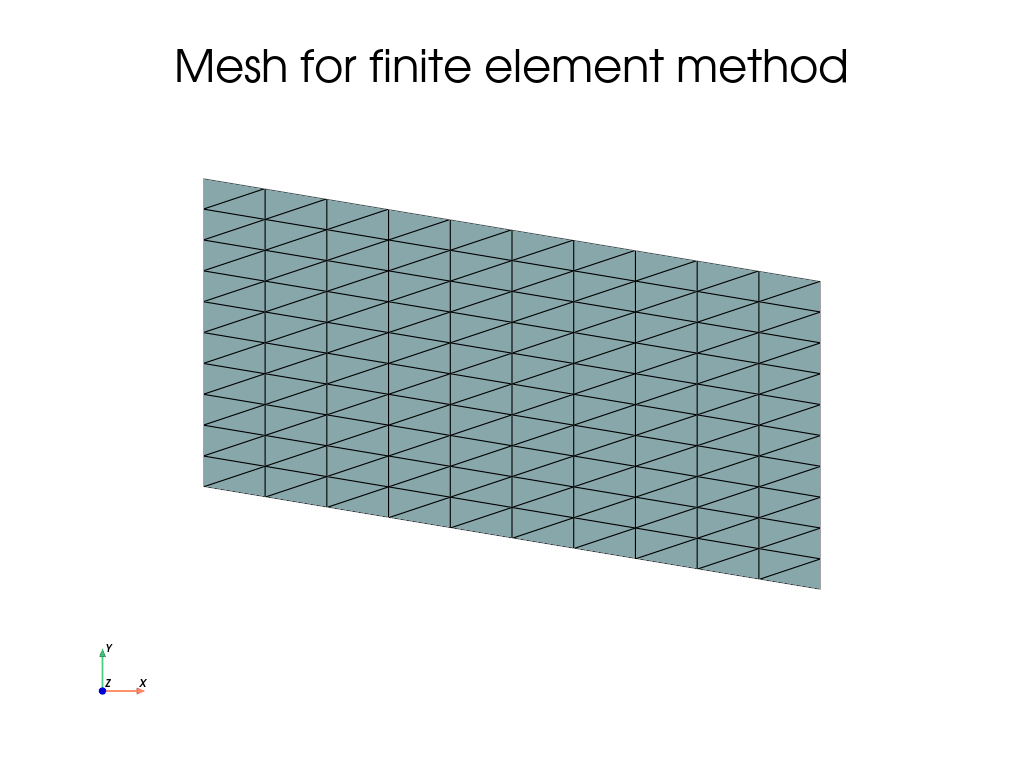

In [3]:
from visualization_fct import plot_mesh2
# Generate domain from four corner points
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
domain = create_quad_domain(MPI.COMM_WORLD, 10, 10, P0, P1, P2, P3)
plot_mesh2(domain)

### Define variational problem

In [4]:
# Define soil parameters for loam
alpha = 3.6
N = 1.56
theta_r = 0.078
theta_s = 0.43
Ks = 2.89e-6

In [28]:
# Soil parameters for silty clay
alpha = 0.56
N = 2
beta = 0.19
Ks = 5.56e-8

In [5]:
# Create functionspace
V = functionspace(domain, ("CG", 1)) # linear Lagrange triangles
v = TestFunction(V)

def kr(u):
    S = (1 + (alpha * u)**N)**((1 - N) / N)
    kr = S**(0.5)*(1 - (1 - S**(N / (N - 1))) **((N - 1) / N))**2
    return kr
"""
def kr(u):
    return exp(beta*u)
"""
x = SpatialCoordinate(domain)


### Define custom integration measures ds
Following https://jsdokken.com/dolfinx-tutorial/chapter3/robin_neumann_dirichlet.html <br>
Define $\Gamma_{bed}$ to be boundary 1, $\Gamma_D$ boundary 2 (where we assume the groundwater table is at 0), $\Gamma_{out}$ is boundary 3 and $\Gamma_{in}$ boundary 4.

In [6]:
# Boundary conditions
slope = (P1[1]-P0[1])/(P1[0]-P0[0]) # slope of bottom and top boundary

# Define the gw table at the right boundary to be below 0.
def on_dirichlet(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] <= 0)
def gamma_out(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] >= 0)
def gamma_in(x):
    return np.isclose(x[1], slope*x[0]+P3[1])
def bottom(x):
    return np.isclose(x[1], slope*x[0])
def gamma_bed(x):
    return np.logical_or(bottom(x), np.isclose(x[0], 0))

In [7]:
boundaries = [
    (1, gamma_bed),
    (2, on_dirichlet),
    (3, gamma_out),
    (4, gamma_in)
]

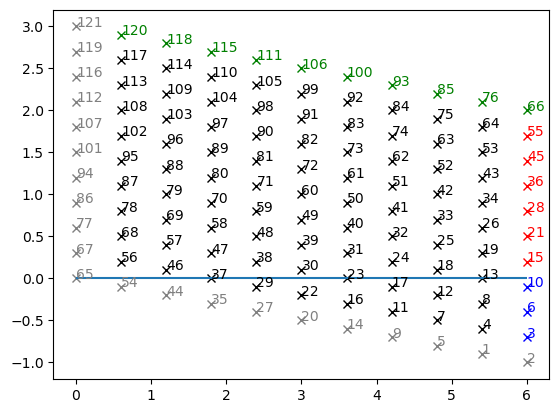

In [8]:
# Check, if the right boundaries are identified
pts = domain.geometry.x # mesh coordinates of the vertices shape=(num_points, 3)
pts = np.array(pts)
import matplotlib.pyplot as plt
for i, p in enumerate(pts):
    i += 1
    if gamma_bed(p):
        c = "grey"
    elif gamma_in(p):
        c = "green"
    elif gamma_out(p):
        c = "red"
    elif on_dirichlet(p):
        c = "blue"
    else:
        c = "black"
    plt.plot(p[0], p[1], 'x', color=c)
    plt.annotate(str(i), (p[0], p[1]), color=c)
plt.hlines(0, min(pts[:,0]), max(pts[:,0]))

In [9]:
# We now loop through all the boundary conditions and create MeshTags identifying the facets for each boundary condition.
facet_indices, facet_markers = [], []
fdim = domain.topology.dim - 1
for marker, locator in boundaries:
    facets = locate_entities(domain, fdim, locator) # find boundary facet
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32) # make array of arrays into single array
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = meshtags(
    domain, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets]
) # each boundary facet gets identified with its boundary condition

domain.topology.create_connectivity(fdim, domain.topology.dim) # connect facets to cells

In [10]:
# Create custom integration measure
ds = Measure("ds", domain, subdomain_data=facet_tag)

I think this is not needed in this instance

In [11]:
# Create general boundary condition class
class BoundaryCondition:
    def __init__(self, type, marker, values):
        self._type = type
        if type == "Dirichlet":
            facets = facet_tag.find(marker)
            dofs = locate_dofs_topological(V, fdim, facets)
            self._bc = dirichletbc(PETSc.ScalarType(values), dofs, V)
        elif type == "Neumann":
            self._bc = inner(values, v) * ds(marker)
        else:
            raise TypeError("Unknown boundary condition: {0:s}".format(type))

    @property
    def bc(self):
        return self._bc

    @property
    def type(self):
        return self._type

In [12]:
# Define boundary conditions
c_in = -2e-9 # recharge
c_out = 1e-10 # outflow
boundary_conditions = [
    BoundaryCondition("Neumann", 1, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Dirichlet", 2, 0),
    BoundaryCondition("Neumann", 3, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Neumann", 4, Constant(domain, default_scalar_type(c_in)))
]

In [13]:
bcs = []
#F = dot(kr(u)*Ks*grad(x[1] - u), grad(v))*dx
for condition in boundary_conditions:
    if condition.type == "Dirichlet":
        bcs.append(condition.bc)
    #else:
        # F += condition.bc

### Picard Iteration

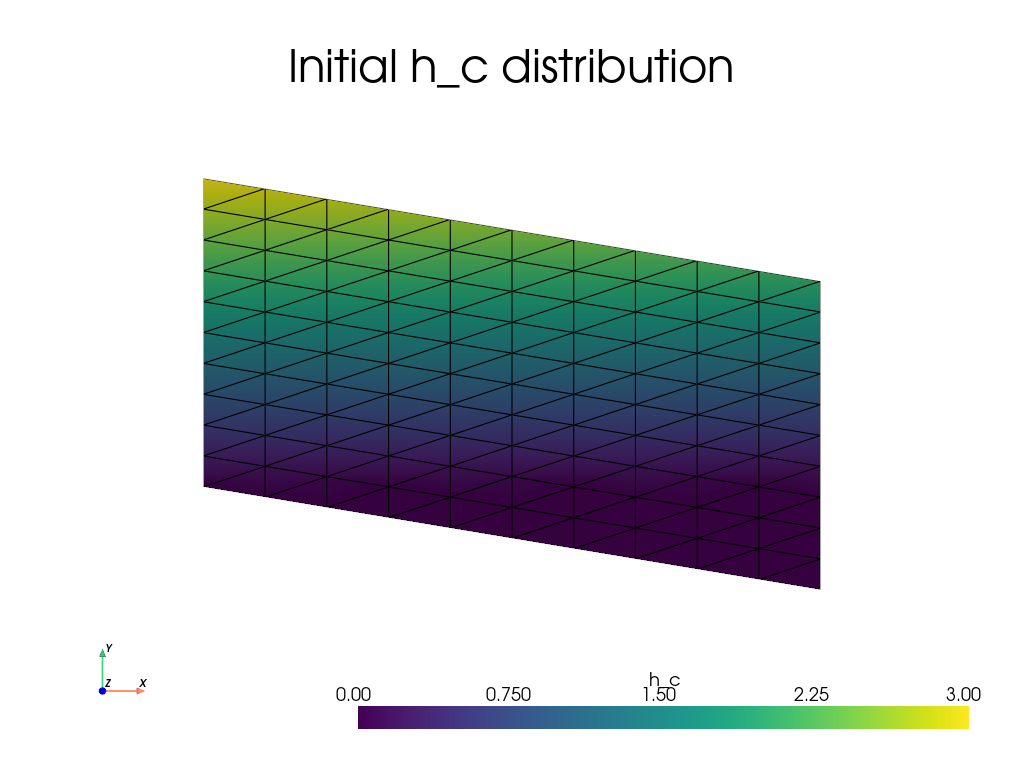

Iteration 1, Error ||u_k-u_(k+1)|| 1.278e+01
Iteration 2, Error ||u_k-u_(k+1)|| 8.427e+00
Iteration 3, Error ||u_k-u_(k+1)|| 4.940e+00
Iteration 4, Error ||u_k-u_(k+1)|| 4.280e+00
Iteration 5, Error ||u_k-u_(k+1)|| 5.053e+00
Iteration 6, Error ||u_k-u_(k+1)|| 5.254e+00
Iteration 7, Error ||u_k-u_(k+1)|| 3.953e+00
Iteration 8, Error ||u_k-u_(k+1)|| 1.795e+00
Iteration 9, Error ||u_k-u_(k+1)|| 1.124e+00
Iteration 10, Error ||u_k-u_(k+1)|| 8.055e-01
Iteration 11, Error ||u_k-u_(k+1)|| 8.147e-01
Iteration 12, Error ||u_k-u_(k+1)|| 7.536e-01
Iteration 13, Error ||u_k-u_(k+1)|| 6.211e-01
Iteration 14, Error ||u_k-u_(k+1)|| 4.821e-01
Iteration 15, Error ||u_k-u_(k+1)|| 3.150e-01
Iteration 16, Error ||u_k-u_(k+1)|| 1.767e-01
Iteration 17, Error ||u_k-u_(k+1)|| 6.764e-02
Iteration 18, Error ||u_k-u_(k+1)|| 2.681e-02
Iteration 19, Error ||u_k-u_(k+1)|| 2.524e-02
Iteration 20, Error ||u_k-u_(k+1)|| 1.451e-02
Iteration 21, Error ||u_k-u_(k+1)|| 8.304e-03
Iteration 22, Error ||u_k-u_(k+1)|| 1.035e-

In [15]:
# Initial guess: hydrostatic (h_c = height above gw table)
def u_ini(x):
    return np.maximum(x[1], 0)
    
u_k = Function(V)
u_k.interpolate(u_ini) # previous (known) solution

u = TrialFunction(V)

F = inner(kr(u_k) * Ks * grad(x[1] - u), grad(v)) * dx + v*c_in*ds(4)
a = lhs(F)
L = rhs(F)

plotScalarFunction(V, u_k, name="h_c", title="Initial h_c distribution")

# Picard Iteration
u = Function(V) # u_{k+1} next step solution
eps = 1.0 # error measure ||u-u_k||
tol = 1e-6 # tolerance
it = 0 # iteration counter
maxiter = 75 # max number of iterations allowed

while eps > tol and it < maxiter:
    it += 1
    problem = LinearProblem(
        a, L, bcs=bcs,
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
        petsc_options_prefix="Richards_"
    )
    u = problem.solve()
    u.x.array[:] = np.maximum(u.x.array, 0) # make sure capillary head stays nonnegative
    diff = u.x.array - u_k.x.array
    eps = np.linalg.norm(diff, ord=2)
    print(f"Iteration {it}, Error ||u_k-u_(k+1)|| {eps:.3e}")
    u_k.x.array[:] = u.x.array
    if eps <= tol:
        print(f"Iteration terminated due to error measure ||u_k-u_(k+1)|| = {eps:.2e} being smaller than {tol}.")
    if it >= maxiter:
        print(f"Iteration terminated due to maximum number of iterations reached.")
    




### Analyse solution

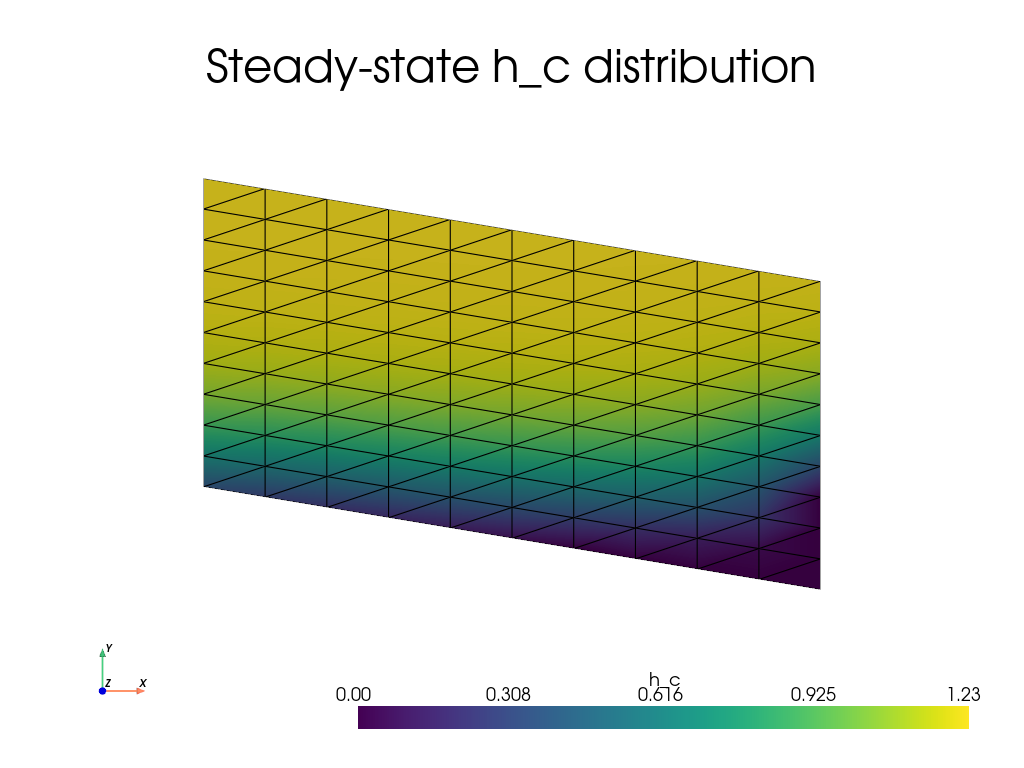

In [16]:
plotScalarFunction(V, u, title="Steady-state h_c distribution", name="h_c")

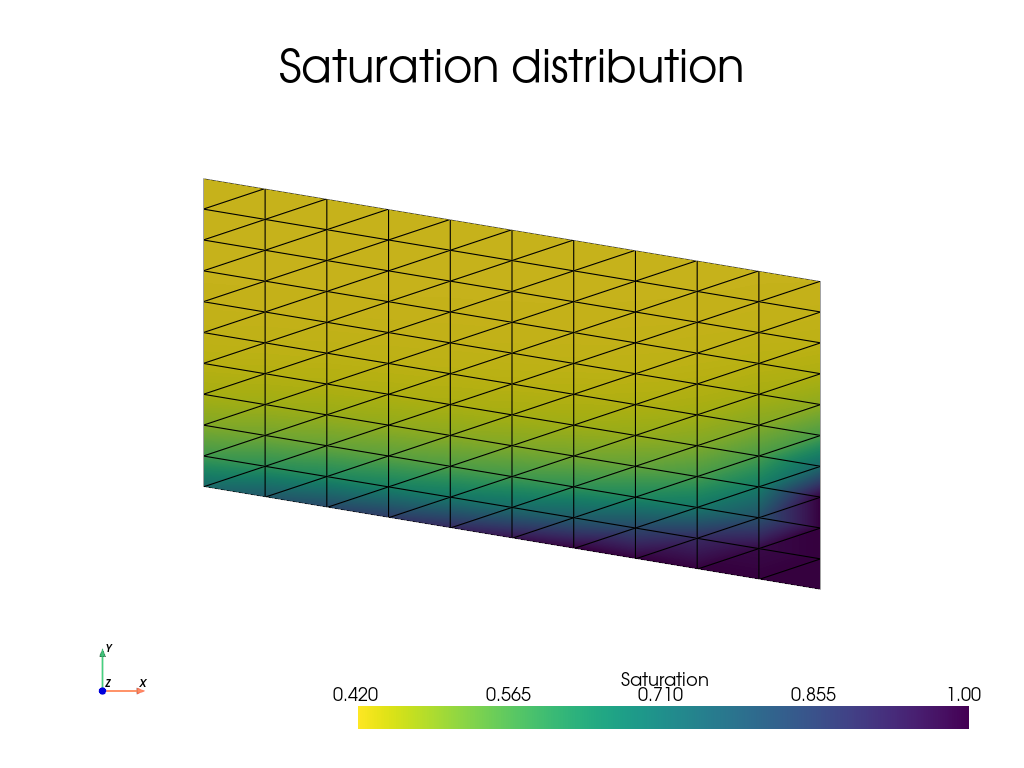

In [17]:
def Saturation(h_c):
    S = (1 + (alpha * h_c)**N)**((1 - N) / N)
    return S

S = Saturation(u.x.array)
plotScalarFunction(V, S, name="Saturation", title="Saturation distribution", fct_as_array=True, cmap="viridis_r")

In [ ]:
# Try and compute q
def compute_flux(u, kr, Ks, mesh):
    # Project the flux into vector space
    W = functionspace(mesh, ("Lagrange", 1, (mesh.geometry.dim,)))
    x = SpatialCoordinate(domain)
    q_expr = -kr(u) * Ks * grad(x[1]-u)

    v = TestFunction(W)
    w = TrialFunction(W)

    a = inner(w, v) * dx
    L = inner(q_expr, v) * dx

    # Identify bottom DOFs
    bottom_dofs = locate_dofs_geometrical(W, gamma_bed)

    # Create zero-flux Dirichlet BC
    bc = dirichletbc(np.zeros(mesh.geometry.dim, dtype=np.float64), bottom_dofs, W)


    problem = LinearProblem(a, L, bcs=[bc], petsc_options_prefix="get_q_")
    return W, problem.solve()

W, q = compute_flux(u, kr, Ks, domain)

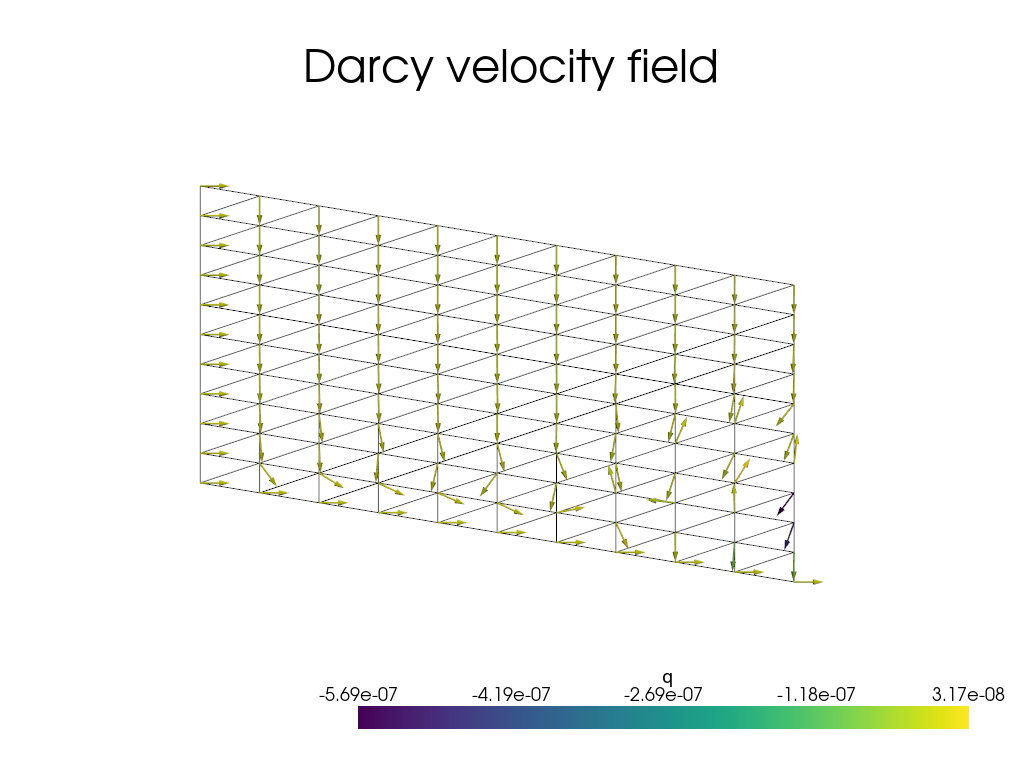

In [21]:
# Plot q
topology, cell_types, geometry = vtk_mesh(W)
values = np.zeros((geometry.shape[0], 3), dtype=np.float64)
values[:, :domain.geometry.dim] = q.x.array.real.reshape(
    geometry.shape[0], domain.geometry.dim
)
# Create a point cloud of glyphs
pyvista.set_jupyter_backend("static")
function_grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
function_grid["q"] = values
glyphs = function_grid.glyph(orient="q", scale= False, factor=0.3)

# Create a pyvista-grid for the mesh
tdim = domain.topology.dim
domain.topology.create_connectivity(tdim, tdim)
grid = pyvista.UnstructuredGrid(*vtk_mesh(domain, tdim))

# Create plotter
plotter = pyvista.Plotter()
plotter.add_mesh(grid, style="wireframe", color="k")
plotter.add_mesh(glyphs, scalar_bar_args={"title": "||q||"})
plotter.add_title("Darcy velocity field")
plotter.view_xy()

if not pyvista.OFF_SCREEN:
    plotter.show()

### To do:
- saturation plotten
- q
- analytische lsg
- transient
- heterogenität
- newton?

### Solve with built-in Newton solver

In [43]:
# Define variational problem for built-in solver

""" u = Function(V)
F = F = inner(kr(u) * Ks * grad(x[1] - u), grad(v)) * dx + v*c_in*ds(4) """

' u = Function(V)\nF = F = inner(kr(u) * Ks * grad(x[1] - u), grad(v)) * dx + v*c_in*ds(4) '

In [44]:
""" petsc_options = {
    "snes_type": "newtonls",
    "snes_atol": 1e-3,
    "snes_rtol": 1e-3,
    "snes_monitor": None,
    "ksp_error_if_not_converged": True,
    "ksp_type": "gmres",
    "ksp_rtol": 1e-8,
    "ksp_monitor": None,
    "pc_type": "hypre",
    "pc_hypre_type": "boomeramg",
    "pc_hypre_boomeramg_max_iter": 1,
    "pc_hypre_boomeramg_cycle_type": "v",
} """

' petsc_options = {\n    "snes_type": "newtonls",\n    "snes_atol": 1e-3,\n    "snes_rtol": 1e-3,\n    "snes_monitor": None,\n    "ksp_error_if_not_converged": True,\n    "ksp_type": "gmres",\n    "ksp_rtol": 1e-8,\n    "ksp_monitor": None,\n    "pc_type": "hypre",\n    "pc_hypre_type": "boomeramg",\n    "pc_hypre_boomeramg_max_iter": 1,\n    "pc_hypre_boomeramg_cycle_type": "v",\n} '

In [45]:
""" problem = NonlinearProblem(
    F,
    u,
    bcs=bcs,
    petsc_options=petsc_options,
    petsc_options_prefix="nonlinRichards",
) """

' problem = NonlinearProblem(\n    F,\n    u,\n    bcs=bcs,\n    petsc_options=petsc_options,\n    petsc_options_prefix="nonlinRichards",\n) '

In [46]:
""" problem.solve()
converged = problem.solver.getConvergedReason()
num_iter = problem.solver.getIterationNumber()
assert converged > 0, f"Solver did not converge, got {converged}."
print(
    f"Solver converged after {num_iter} iterations with converged reason {converged}."
) """

' problem.solve()\nconverged = problem.solver.getConvergedReason()\nnum_iter = problem.solver.getIterationNumber()\nassert converged > 0, f"Solver did not converge, got {converged}."\nprint(\n    f"Solver converged after {num_iter} iterations with converged reason {converged}."\n) '